<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/Fake_and_Real_News_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake and Real News Classification

This notebook explores fake news classification using TF-IDF vectorisation and Logistic Regression.

The analysis includes:
- exploratory data analysis (EDA)
- title vs full-text classification
- TF-IDF feature analysis
- feature importance inspection
- false positive analysis
- word cloud visualisation
- observations about dataset bias and source-related patterns

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Path to dataset files: /kaggle/input/fake-and-real-news-dataset


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
print(os.listdir(path))

['True.csv', 'Fake.csv']


In [4]:
true_df = pd.read_csv(os.path.join(path, 'True.csv'))
fake_df = pd.read_csv(os.path.join(path, 'Fake.csv'))

In [5]:
true_df["label"] = 0
fake_df["label"] = 1

In [6]:
df= pd.concat([fake_df, true_df], axis=0)

In [7]:
df = df.sample(frac=1, random_state = 42).reset_index(drop=True)

#■ 데이터 확인

In [8]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


In [9]:
df.shape

(44898, 5)

In [10]:
df["label"].value_counts()

,count
label,
1,23481
0,21417


In [11]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [12]:
df['subject'].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [13]:
df.groupby("label")['subject'].value_counts()

label  subject        
0      politicsNews       11272
       worldnews          10145
1      News                9050
       politics            6841
       left-news           4459
       Government News     1570
       US_News              783
       Middle-east          778
Name: count, dtype: int64

In [14]:
df["text_length"] = df["text"].str.len()
df.head()

,title,text,subject,date,label,text_length
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1,1028
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0,4820
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0,1848
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1,1244
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0,3137


In [15]:
df.groupby("label")["text_length"].describe()
# 평균은 유사하지만, fake가 std가 크고, 전체적으로 길다(25%에서 이미 500자 차이)

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,21417.0,2383.278517,1684.835730,1.0,914.0,2222.0,3237.0,29781.0
1,23481.0,2547.396235,2532.884399,1.0,1433.0,2166.0,3032.0,51794.0


In [16]:
df["word_count"] = df["text"].str.split().str.len()
df.head()

,title,text,subject,date,label,text_length,word_count
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1,1028,171
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0,4820,771
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0,1848,304
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1,1244,183
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0,3137,529


In [17]:
df.groupby("label")["word_count"].describe()
# fake가 단어 수가 더 많음

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,21417.0,385.640099,274.006204,0.0,148.0,359.0,525.0,5172.0
1,23481.0,423.197905,408.388890,0.0,240.0,363.0,506.0,8135.0


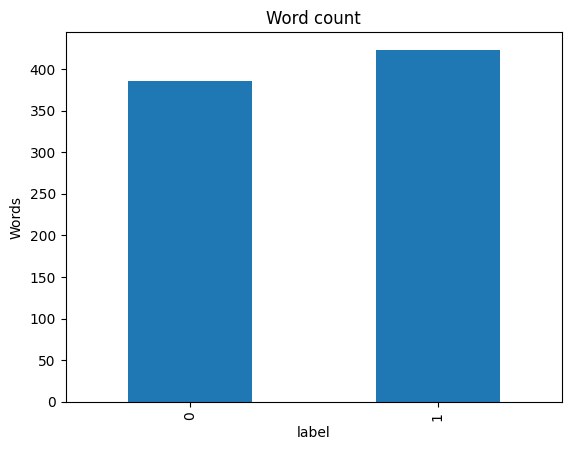

In [21]:
df.groupby("label")["word_count"].mean().plot(kind="bar")
plt.ylabel("Words")
plt.title("Word count")
plt.show()

In [18]:
df["title_length"] = df["title"].str.len()
df.groupby("label")["title_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,21417.0,64.667881,9.168999,26.0,59.0,64.0,70.0,133.0
1,23481.0,94.198032,27.184433,8.0,77.0,90.0,105.0,286.0


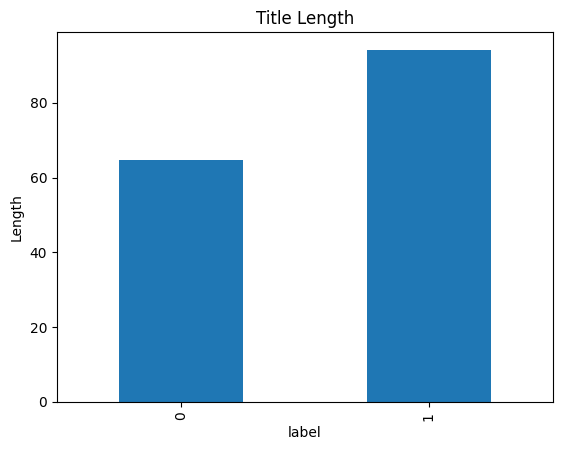

In [22]:
df.groupby("label")["title_length"].mean().plot(kind="bar")
plt.ylabel("Length")
plt.title("Title Length")
plt.show()

#■ ML

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_title = df["title"]
y = df["label"]

In [25]:
X_title_train, X_title_test, y_train, y_test = train_test_split(X_title, y,     test_size= 0.2, random_state= 42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

## ■ Title / Text Model

In [27]:
# Title만 고려하는 모델

model_title = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features = 50000,
        ngram_range = (1,2),
        stop_words = "english"
    )),
    ("clf", LogisticRegression(
        max_iter = 1000
    ))
])

In [28]:
model_title.fit(X_title_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [29]:
y_title_pred = model_title.predict(X_title_test)

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

In [32]:
print(classification_report(y_title_pred, y_test))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      4376
           1       0.94      0.96      0.95      4604

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



In [33]:
X_text = df["text"]

In [34]:
X_text_train, X_text_test, y_train, y_test = train_test_split(X_text, y,     test_size= 0.2, random_state= 42)

In [35]:
# Text만 고려하는 모델

model_text = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features = 50000,
        ngram_range = (1,2),
        stop_words = "english"
    )),
    ("clf", LogisticRegression(
        max_iter = 1000
    ))
])

In [36]:
model_text.fit(X_text_train, y_train)
# 55초 소요 : 오래걸림

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [37]:
y_text_pred = model_text.predict(X_text_test)

In [38]:
print(classification_report(y_text_pred, y_test))
# title만 고려한 것보다 훨씬 높음
# precision과 recall이 비슷 > 균형있다

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4304
           1       0.98      0.99      0.99      4676

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [40]:
title_proba = model_title.predict_proba(X_title_test)[:,1]

In [41]:
text_proba = model_text.predict_proba(X_text_test)[:,1]

# ■ 실제 데이터 확인

In [45]:
results = pd.DataFrame({
    "title" : X_title_test,
    "text" : X_text_test,
    "actual" : y_test,
    "predict_title" : y_title_pred,
    "predict_text" : y_text_pred,
    "proba_title" : title_proba,
    "proba_text" : text_proba
})

results.sort_values("proba_text", ascending=False).head()

,title,text,actual,predict_title,predict_text,proba_title,proba_text
29029,Watch Confused Trump Wander Aimlessly Away Fr...,Amid news of the Russian scandal and Congress ...,1,1,1,0.999859,0.999763
17164,RUSH LIMBAUGH ASKS: “What Would America Be Lik...,Rush Limbaugh is spot on with his analysis of ...,1,1,1,0.981123,0.999684
14894,RUSH LIMBAUGH ASKS: “What Would America Be Lik...,Rush Limbaugh is spot on with his analysis of ...,1,1,1,0.981123,0.999684
5360,“Dear Mr. Trump”…NBC Uses Kids To Make STUNNIN...,NBC News handpicked anti-Trump tykes for two p...,1,1,1,0.980568,0.999650
25984,"WATCH: THESE ARE THE LEFTISTS Mitt Romney, Joh...","Earlier this week, prominent members of the GO...",1,1,1,0.986920,0.999597


In [64]:
results_fn = results[
    (results["predict_text"] == 0) & (results["predict_title"]==0) & (results["actual"] == 1)
].sort_values("proba_text", ascending=False)

results_fn

,title,text,actual,predict_title,predict_text,proba_title,proba_text
23890,North Korea Promises To “Mercilessly Wipe Out...,North Korea is now vowing to mercilessly wipe...,1,0,0,0.154773,0.493536
39227,GERMANY ELECTION BOMBSHELL: OPEN BORDERS Angel...,"It appears that Obama ally, Angela Merkel is m...",1,0,0,0.431300,0.474789
6312,IS PUERTO RICO THE NEXT DETROIT?,This entire situation with Puerto Rico reminds...,1,0,0,0.122600,0.463921
36723,HOUSE TAKES Measures To Impeach IRS Chief Afte...,Speaker Paul Ryan said Wednesday the House wil...,1,0,0,0.404265,0.451504
10430,Jimmy Carter: ‘Koreans Want Peace Treaty to Re...,21st Century Wire says Reframing the current d...,1,0,0,0.449017,0.411509
38403,TRUMP TELLS State Department To Make CUT More ...,President Trump s administration has told the ...,1,0,0,0.347653,0.386855
25865,"RUSSIA HAMMERS ISIS…Kills 600 Jihadis, As Chin...",Remember when the US had a President who took ...,1,0,0,0.476572,0.384715
5525,U.S. APOLOGIZES FOR HUMAN RIGHTS VIOLATIONS AT...,Obama s apology tour for the greatest country ...,1,0,0,0.352561,0.361163
36746,U.S. APOLOGIZES FOR HUMAN RIGHTS VIOLATIONS AT...,Obama s apology tour for the greatest country ...,1,0,0,0.352561,0.361163
10835,SENATE PASSES USA FREEDOM ACT,McConnell was shut down completely in this deb...,1,0,0,0.235532,0.360392


In [65]:
results_fp = results[
    (results["predict_text"] == 1) & (results["predict_title"] == 1) & (results["actual"] == 0)
].sort_values("proba_text", ascending=True)

results_fp
# 공통적으로 (Reuters)가 있음 < 이게 원인인지?

,title,text,actual,predict_title,predict_text,proba_title,proba_text
5386,"Comey talks 'real world,' meets protests at bl...",WASHINGTON (Reuters) - Protesters at Howard Un...,0,1,1,0.680391,0.508253
39381,Obama drinks coconut water to cool down in Laos,U.S. President Barack Obama visited a street m...,0,1,1,0.752320,0.514808
12804,"For Islamophobia, take two of these and call a...",CLEVELAND (Reuters) - The normally straight-la...,0,1,1,0.912224,0.537335
12075,Memories in milk bottles: Polish exhibition 's...,WARSAW (Reuters) - A deeply moving exhibition ...,0,1,1,0.654159,0.553936
42609,Trump loves 'the poorly educated' ... and soci...,(Reuters) - U.S. presidential candidate Donald...,0,1,1,0.573264,0.591758
11288,Obama says attacks on police hurt Black Lives ...,MADRID (Reuters) - U.S. President Barack Obama...,0,1,1,0.571238,0.607317
38610,Milwaukee County sheriff rescinds Homeland Sec...,(Reuters) - Milwaukee County Sheriff David Cla...,0,1,1,0.505677,0.609203
23307,L'Oreal sacks transgender model after comments...,PARIS (Reuters) - French cosmetics giant L Ore...,0,1,1,0.542477,0.610038
35545,Guantanamo shrinking but Obama goal of closing...,"GUANTANAMO BAY U.S. NAVAL BASE, Cuba (Reuters)...",0,1,1,0.533705,0.623131
2265,Russia's response to Trump leak reports: don't...,(Reuters) - A Russian Foreign Ministry spokesw...,0,1,1,0.539492,0.701240


# ■ Coef 확인

In [58]:
# title 버전

vectorizer_title = model_title.named_steps["tfidf"]
feature_names_title = vectorizer_title.get_feature_names_out()
coefficients_title = model_title.named_steps["clf"].coef_[0]

# text 버전

vectorizer_text = model_text.named_steps["tfidf"]
feature_names_text = vectorizer_text.get_feature_names_out()
coefficients_text = model_text.named_steps["clf"].coef_[0]

In [61]:
importance_title = pd.DataFrame({
    "word" : feature_names_title,
    "coef" : coefficients_title
}).sort_values("coef", ascending = False)

importance_title.head(30)

,word,coef
46520,video,21.676879
17892,hillary,9.676886
47840,watch,9.175777
5486,breaking,8.539877
19510,just,8.096133
17046,gop,7.969981
45222,tweets,5.003604
2476,america,4.964960
23503,muslim,4.583491
30938,racist,4.379431


In [62]:
importance_text = pd.DataFrame({
    "word" : feature_names_text,
    "coef" : coefficients_text
}).sort_values("coef", ascending = False)

importance_text.head(30)
# featured image, com 등등 타 사이트 링크 관련이 꽤 있음

,word,coef
22834,just,6.203114
34855,read,5.403798
20492,image,5.126838
15803,featured,5.018750
15804,featured image,5.008358
33303,president trump,4.884479
17942,gop,4.736747
27921,mr,4.692995
19639,hillary,4.635400
29420,obama,4.442911


In [81]:
importance_text[importance_text["word"]=="trump"]

,word,coef
45379,trump,0.981908


In [73]:
X_train_tfidf = vectorizer_text.fit_transform(X_text_train)

In [83]:
fake_mask = (y_train.values == 1)

fake_tfidf_mean = X_train_tfidf[fake_mask].mean(axis=0)

In [84]:
fake_tfidf_mean = np.asarray(fake_tfidf_mean).flatten()

In [85]:
fake_words = pd.DataFrame({
    "word": feature_names_text,
    "mean_tfidf": fake_tfidf_mean
})

fake_words.sort_values(
    "mean_tfidf",
    ascending=False
).head(20)

# 주로 대통령 이름들

,word,mean_tfidf
45379,trump,0.051923
8176,clinton,0.019448
31318,people,0.017591
29420,obama,0.017372
33148,president,0.016658
19639,hillary,0.016115
22834,just,0.015868
37800,said,0.015524
24730,like,0.014356
13215,donald,0.013039


In [86]:
real_mask = (y_train.values == 0)

real_tfidf_mean = X_train_tfidf[real_mask].mean(axis=0)

In [87]:
real_tfidf_mean = np.asarray(real_tfidf_mean).flatten()

In [89]:
real_words = pd.DataFrame({
    "word": feature_names_text,
    "mean_tfidf": real_tfidf_mean
})

real_words.sort_values(
    "mean_tfidf",
    ascending=False
).head(20)

# trump 말고는 대통령 이름이 나오지는 않음
# reuters 가 3위 : 위의 FP prediction(text) 상위항목들 다 reuters가 포함되었었음

,word,mean_tfidf
37800,said,0.052998
45379,trump,0.035715
36528,reuters,0.025228
33148,president,0.020302
41862,state,0.017477
18035,government,0.016777
20005,house,0.016266
36015,republican,0.014934
48335,washington,0.014574
46940,united,0.014474


# ■ WordCloud

In [82]:
from wordcloud import WordCloud

In [96]:
fake_title = " ".join(
    df[df["label"] == 1]["title"]
)
# fake_title를 한 줄로 이어붙이기(wordcloud에 넣기 위해)
# text로는 의미 없었음 > title이 낫다

In [97]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords="english"
).generate(fake_title)

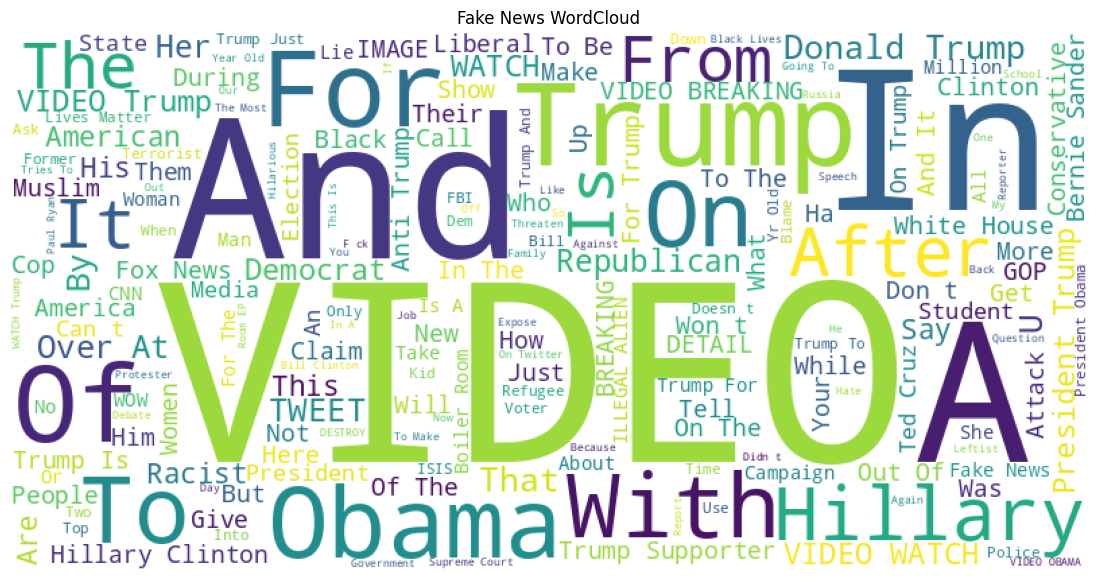

In [98]:
plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Fake News WordCloud")
plt.show()

In [99]:
real_title = " ".join(
    df[df["label"] == 0]["title"]
)
# real_title를 한 줄로 이어붙이기(wordcloud에 넣기 위해)
# text로는 의미 없었음 > title이 낫다

In [101]:
wordcloud2 = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords="english"
).generate(real_title)

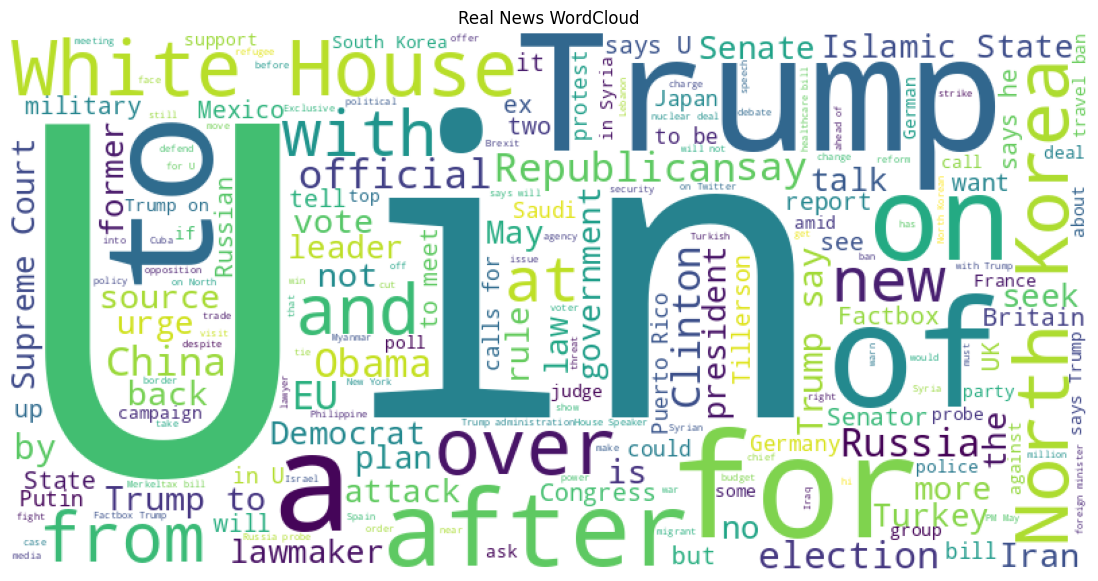

In [102]:
plt.figure(figsize=(15,7))
plt.imshow(wordcloud2)
plt.axis("off")
plt.title("Real News WordCloud")
plt.show()

## Conclusion

- Full article text achieved higher classification performance than title-only input, reaching near-perfect scores on this dataset.
- However, title-only classification also performed strongly, suggesting that headline framing itself contains substantial predictive signal.
- Feature analysis showed strong associations with political names and news-source-related wording.
- Reuters appeared frequently in real-news articles and may have acted as a source-related signal in classification, although it was not sufficient on its own to determine predictions.
- These results suggest that high performance in fake news classification may partially reflect source/style patterns rather than deep semantic understanding of factuality.

This notebook focused not only on model performance, but also on inspecting how linguistic patterns and dataset structure can influence NLP classification results.